In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
tolgadincer_labeled_chest_xray_images_path = kagglehub.dataset_download('tolgadincer/labeled-chest-xray-images')

print('Data source import complete.')


Using Colab cache for faster access to the 'labeled-chest-xray-images' dataset.
Data source import complete.


🧠 Advanced Image Segmentation Using CNN & U-Net Architecture  
## 🔍 Project Overview

This project aims to develop a high-precision Image Segmentation framework leveraging Convolutional Neural Networks (CNN) and the U-Net architecture. The primary objective is to perform pixel-level segmentation by detecting and outlining regions of interest within images, enabling deeper visual understanding beyond traditional classification tasks.

### 🛠 Key Components of the Workflow:

- Comprehensive data preprocessing and augmentation  
- Implementation of U-Net for semantic segmentation  
- Integration of CNN models for hierarchical feature extraction  
- Model training, validation, and hyperparameter tuning  
- Evaluation using industry-standard segmentation metrics  
- Visualization of ground-truth vs. predicted masks  

This system demonstrates the potential of deep learning to achieve accurate and reliable segmentation results, positioning it as a strong candidate for use in domains such as medical imaging, autonomous systems, remote sensing, and industrial quality inspection.


In [2]:
import os
import cv2
import numpy as np
from tqdm import tqdm

data_dir = '/kaggle/input/labeled-chest-xray-images/chest_xray/train'
mask_output_dir = '/kaggle/working/masks'

os.makedirs(mask_output_dir, exist_ok=True)

def create_mask(image_path, threshold=100):
    gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY_INV)
    return mask

for label in ['NORMAL', 'PNEUMONIA']:
    input_folder = os.path.join(data_dir, label)
    output_folder = os.path.join(mask_output_dir, label)
    os.makedirs(output_folder, exist_ok=True)

    for img_file in tqdm(os.listdir(input_folder)):
        img_path = os.path.join(input_folder, img_file)
        mask = create_mask(img_path)
        mask_path = os.path.join(output_folder, img_file)
        cv2.imwrite(mask_path, mask)


100%|██████████| 3883/3883 [00:58<00:00, 66.14it/s]


# MODEL For SEGMENT AND CLASSIFICATION

In [11]:
from tensorflow import keras
from tensorflow.keras import layers, models

def build_multi_task_model(input_shape=(150, 150, 3)):
    inputs = layers.Input(shape=input_shape)

    # Shared encoder
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D()(x)

    # Classification branch
    flat = layers.Flatten()(encoded)
    class_output = layers.Dense(64, activation='relu')(flat)
    class_output = layers.Dense(1, activation='sigmoid', name='classification')(class_output)

    # Segmentation branch
    x = layers.Conv2DTranspose(128, 3, strides=2, padding='same', activation='relu')(encoded)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(16, 3, strides=2, padding='same', activation='relu')(x)
    seg_output = layers.Cropping2D(cropping=((69, 69), (69, 69)))(x)
    seg_output = layers.Conv2D(1, 1, activation='sigmoid', name='segmentation')(seg_output)

    return models.Model(inputs=inputs, outputs=[class_output, seg_output])

# Prepare Data For Model


In [12]:
from tensorflow.keras.utils import Sequence
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import os

class ChestXrayDataGenerator(Sequence):
    def __init__(self, image_dir, mask_dir, batch_size=16, target_size=(150, 150), shuffle=True):
        self.image_paths = []
        self.mask_paths = []
        self.labels = []
        self.batch_size = batch_size
        self.target_size = target_size
        self.shuffle = shuffle

        for label in ['NORMAL', 'PNEUMONIA']:
            img_folder = os.path.join(image_dir, label)
            mask_folder = os.path.join(mask_dir, label)
            for filename in os.listdir(img_folder):
                self.image_paths.append(os.path.join(img_folder, filename))
                self.mask_paths.append(os.path.join(mask_folder, filename))
                self.labels.append(0 if label == 'NORMAL' else 1)

        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def __getitem__(self, index):
        batch_images = self.image_paths[index*self.batch_size:(index+1)*self.batch_size]
        batch_masks = self.mask_paths[index*self.batch_size:(index+1)*self.batch_size]
        batch_labels = self.labels[index*self.batch_size:(index+1)*self.batch_size]

        images, masks = [], []
        for img_path, mask_path in zip(batch_images, batch_masks):
            img = load_img(img_path, target_size=self.target_size)
            mask = load_img(mask_path, color_mode='grayscale', target_size=self.target_size)

            images.append(img_to_array(img) / 255.0)
            masks.append(img_to_array(mask) / 255.0)

        return np.array(images), {
            'classification': np.array(batch_labels),
            'segmentation': np.array(masks)
        }

    def on_epoch_end(self):
        if self.shuffle:
            zipped = list(zip(self.image_paths, self.mask_paths, self.labels))
            np.random.shuffle(zipped)
            self.image_paths, self.mask_paths, self.labels = zip(*zipped)


# Train Model

In [13]:
train_generator = ChestXrayDataGenerator(
    image_dir='/kaggle/input/labeled-chest-xray-images/chest_xray/train',
    mask_dir='/kaggle/working/masks',
    batch_size=8
)

model = build_multi_task_model()
model.compile(
    optimizer='adam',
    loss={
        'classification': 'binary_crossentropy',
        'segmentation': 'binary_crossentropy'
    },
    metrics={
        'classification': 'accuracy',
        'segmentation': 'accuracy'
    }
)

model.fit(train_generator, epochs=10)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
654/654 ━━━━━━━━━━━━━━━━━━━━ 647s 983ms/step - classification_accuracy: 0.9344 - classification_loss: 0.1676 - loss: 0.6947 - segmentation_accuracy: 0.7004 - segmentation_loss: 0.5271
Epoch 2/10
654/654 ━━━━━━━━━━━━━━━━━━━━ 642s 981ms/step - classification_accuracy: 0.9683 - classification_loss: 0.0842 - loss: 0.5501 - segmentation_accuracy: 0.7509 - segmentation_loss: 0.4659
Epoch 3/10
654/654 ━━━━━━━━━━━━━━━━━━━━ 634s 969ms/step - classification_accuracy: 0.9786 - classification_loss: 0.0575 - loss: 0.4799 - segmentation_accuracy: 0.7759 - segmentation_loss: 0.4223
Epoch 4/10
654/654 ━━━━━━━━━━━━━━━━━━━━ 635s 970ms/step - classification_accuracy: 0.9859 - classification_loss: 0.0376 - loss: 0.4373 - segmentation_accuracy: 0.7889 - segmentation_loss: 0.3997
Epoch 5/10
654/654 ━━━━━━━━━━━━━━━━━━━━ 637s 975ms/step - classification_accuracy: 0.9883 - classification_loss: 0.0305 - loss: 0.4196 - segmentation_accuracy: 0.7945 - segmentation_loss: 0.3892
Epoch 6/10
654/654 ━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


/tmp/ipykernel_1866/4046817124.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_labels.append(int(pred_class[0] > 0.5))


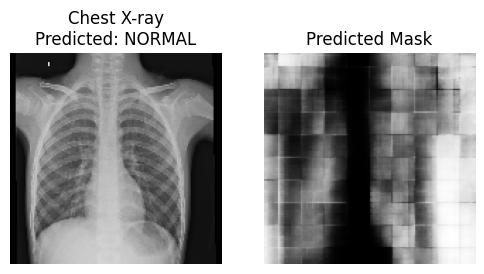

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


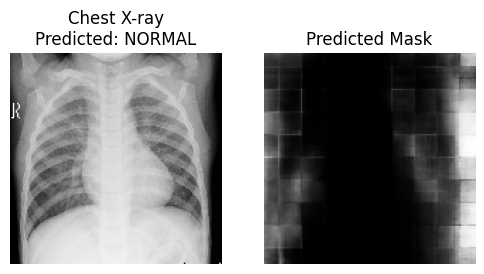

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


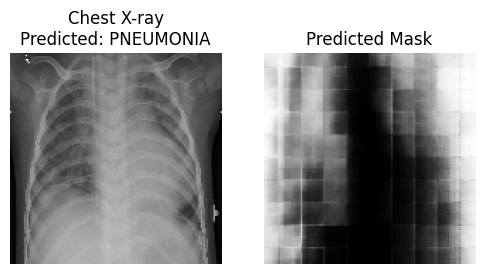

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


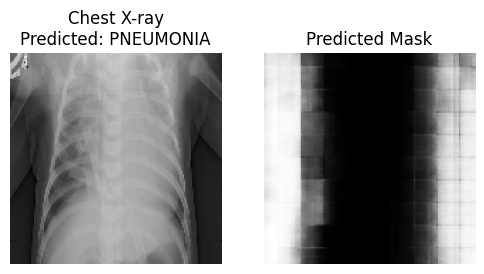


Classification Report:
              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00         2
   PNEUMONIA       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4

Confusion Matrix:
[[2 0]
 [0 2]]


In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

test_paths = [
    '/kaggle/input/labeled-chest-xray-images/chest_xray/test/NORMAL/NORMAL-1049278-0001.jpeg',
    '/kaggle/input/labeled-chest-xray-images/chest_xray/test/NORMAL/NORMAL-1283091-0001.jpeg',
    '/kaggle/input/labeled-chest-xray-images/chest_xray/test/PNEUMONIA/BACTERIA-1135262-0003.jpeg',
    '/kaggle/input/labeled-chest-xray-images/chest_xray/test/PNEUMONIA/BACTERIA-1602272-0002.jpeg',
]

true_labels = [0, 0, 1, 1]
pred_labels = []

for img_path in test_paths:
    img = load_img(img_path, target_size=(150, 150))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred_class, pred_mask = model.predict(img_array)
    pred_labels.append(int(pred_class[0] > 0.5))

    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    plt.title(f"Chest X-ray\nPredicted: {'PNEUMONIA' if pred_class[0] > 0.5 else 'NORMAL'}")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Predicted Mask")
    plt.imshow(pred_mask[0, :, :, 0], cmap='gray')
    plt.axis("off")
    plt.show()

print("\nClassification Report:")
print(classification_report(true_labels, pred_labels, target_names=['NORMAL', 'PNEUMONIA']))

print("Confusion Matrix:")
print(confusion_matrix(true_labels, pred_labels))
